# CME538 - Introduction to Data Science

## Tutorial 4 - JSON, Text Analysis and Visualization

By the end of this tutorial, you should be comfortable:

- Loading JSON data using Python
- Understanding nested JSON structures
- Converting JSON data into a Pandas DataFrame
- Accessing and manipulating nested data
- Applying basic text-cleaning techniques
- Using datetime information in a real dataset
- Creating and interpreting visualizations with Seaborn
- Connecting these techniques to Assignment 3

### Tutorial Structure

1. [Working with JSON](#section1)
   - 1.1. Reading JSON from a file
   - 1.2. Writing JSON to a file
   - 1.3. Accessing data in a nested JSON dictionary

2. [Working with Text](#section2)
   - 2.1. Working with strings
   - 2.2. Removing punctuation and stopwords

3. [Working with Dates and Times](#section3)
   - 3.1. Working with datetime data
   - 3.2. Extracting information from dates

4. [Visualization with Seaborn](#section4)
   - 4.1. Comparing distributions
   - 4.2. Aggregating data
   - 4.3. Choosing an appropriate visualization

## Setup Notebook

At the start of a notebook, we import the Python packages needed for this tutorial.

* **NumPy** — Provides numerical and array-based operations used throughout data science.
* **Pandas** — Provides tools for working with structured data such as DataFrames.
* **Seaborn** — Provides a high-level interface for creating statistical visualizations.
* **Matplotlib** — Provides plotting and customization functionality.

We will also configure the notebook so that plots are displayed directly in the notebook and have a consistent appearance.

In this tutorial, we will use these tools to work with **JSON data, text, and visualizations**.


In [25]:
# Import libraries for JSON files, DataFrames, and visualization.

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display plots directly in the Jupyter Notebook.

%matplotlib inline

# Apply a consistent plotting style.

plt.style.use('fivethirtyeight')

# Set the plotting context for a Jupyter Notebook.

sns.set_context("notebook")

<a id="section1"></a>

# 1. JSON Files Basics

JSON (**JavaScript Object Notation**) is a common format for storing and exchanging structured data. It is widely used when working with APIs, web data, and datasets.

JSON data is organized using **key-value pairs** and can contain nested dictionaries and lists. When JSON is loaded into Python, it is represented using familiar Python data structures such as dictionaries, lists, strings, numbers, booleans, and `None`.

We will first look at a small example to understand the structure of JSON before working with a JSON dataset.

Consider the following Python dictionary:

In [ ]:
# Create a nested dictionary representing information about two family members.

dict_doe_family = {
    "John": {
        "first name": "John",
        "last name": "Doe",
        "gender": "male",
        "age": 30,
        "favorite_animal": "panda",
        "married": True,
        "children": ["James", "Jennifer"],
        "hobbies": ["photography", "sky diving", "reading"]
    },
    "Jane": {
        "first name": "Jane",
        "last name": "Doe",
        "gender": "female",
        "age": 27,
        "favorite_animal": "zebra",
        "married": False,
        "children": None,
        "hobbies": ["cooking", "gaming", "tennis"]
    }
}

### 1.1 Loading JSON Data

The `json.load()` function reads JSON data from a file and converts it into Python objects.

A JSON object is typically loaded as a Python dictionary.

In [34]:
# Read the JSON file and load its contents into a Python dictionary.

with open("Doe.json", "r", encoding="utf8") as file:
    dict_doe_family = json.load(file)

# Check the type of object returned by json.load().

print(type(dict_doe_family))

# Display the loaded data.

print(dict_doe_family)

<class 'dict'>
{'John': {'first name': 'John', 'last name': 'Doe', 'gender': 'male', 'age': 30, 'favorite_animal': 'panda', 'married': True, 'children': ['James', 'Jennifer'], 'hobbies': ['photography', 'sky diving', 'reading']}, 'Jane': {'first name': 'Jane', 'last name': 'Doe', 'gender': 'female', 'age': 27, 'favorite_animal': 'zebra', 'married': False, 'children': None, 'hobbies': ['cooking', 'gaming', 'tennis']}}


### 1.2 Accessing Nested JSON Data

JSON data can contain nested dictionaries and lists.

A dictionary can contain another dictionary as a value, and values can also be lists. This means that accessing information may require multiple levels of keys.

In [35]:
# Write the Python dictionary to a new JSON file.

with open("Doe_copy.json", "w", encoding="utf8") as file:
    json.dump(dict_doe_family, file, indent=4)

### 1.3 Accessing Data in a JSON Dictionary

JSON data can contain **nested structures**. A dictionary can contain another dictionary, and values can also be lists.

This means that accessing information may require multiple levels of keys.

For example, our `dict_doe_family` dictionary contains information about each family member, including a list of hobbies.

Let's access John's information first, and then John's hobbies.


In [ ]:
# Access John's information from the outer dictionary.
john_info = dict_doe_family["John"]

print(john_info)

In [ ]:
# Access John's hobbies from his nested dictionary.
john_hobbies = john_info["hobbies"]

print(john_hobbies)

In [ ]:
# Nested keys can also be accessed in a single expression.
john_hobbies = dict_doe_family["John"]["hobbies"]

print(john_hobbies)

We can also iterate through the dictionary to access information for every family member.

The `.items()` method gives us both the **key** and its corresponding **value**.


In [27]:
# Create an empty list to store the hobbies of each family member.

members_hobbies = []

# Loop through each family member and their information.

for name, info in dict_doe_family.items():
    # Access the hobbies from the nested dictionary.
    hobbies = info["hobbies"]

    # Add the hobbies to our list.
    members_hobbies.append(hobbies)

# Display the collected hobbies.

print(members_hobbies)

[['photography', 'sky diving', 'reading'], ['cooking', 'gaming', 'tennis']]


<a id="section2"></a>

# 2. Working with Text

Text data often contains punctuation, capitalization, and other characters that can make analysis more difficult.

Before analyzing text, we may need to **clean and standardize** it. In this section, we will use Python string methods to:

- Identify punctuation characters
- Remove punctuation from text
- Split text into individual words
- Remove common words, called **stopwords**

These are simple but useful preprocessing steps that will appear again in **Assignment 3: Text Analysis**.

In [ ]:
# Import Python's built-in string module
import string

# Example text containing punctuation
s = "#Hey, Thi$s is a string. With. Punctuation!!!"

# Display the punctuation characters available in Python
string.punctuation

In [ ]:
# Remove punctuation characters from the example string
s_clean = s.translate(str.maketrans('', '', string.punctuation))

# Display the cleaned text
s_clean

### 2.2 Removing Punctuation and Stopwords

Punctuation is not the only thing we may want to remove.

**Stopwords** are very common words such as *the*, *is*, *a*, and *to*. They often carry little useful information for some types of text analysis.

We can use the `nltk` library to obtain a list of English stopwords and remove them from our text.

In [36]:
# Import NLTK and the English stopword list.

import nltk
from nltk.corpus import stopwords

# Download the English stopword list if it is not already available.

nltk.download('stopwords')

# Get the English stopwords.

english_stopwords = set(stopwords.words('english'))

# Split the cleaned text into individual words.

words = s_clean.split()

# Keep words that are not stopwords.

words_filtered = [
    word
    for word in words
    if word.lower() not in english_stopwords
]

# Display the filtered words.

words_filtered

[nltk_data] Downloading package stopwords to /Users/abdullah-
[nltk_data]     cvl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['Hey', 'string', 'Punctuation']

### Why does this matter?

Text preprocessing is usually the first step before performing tasks such as:

- counting word frequencies,
- searching for keywords,
- comparing documents,
- or performing sentiment analysis.

We will use these ideas again in **Assignment 3**, where we work with tweets and analyze their text and sentiment.

<a id="section3"></a>

# 3. Working with Dates and Times

In Tutorial 3, we learned how to work with dates and times in Python.

Here, we will apply those skills to a real-world dataset: the **Open Power System Data (OPSD)** dataset for Germany.

The dataset contains daily observations of:

- electricity consumption;
- wind power production;
- solar power production; and
- combined wind and solar production.

The data covers the period from 2006 to 2017.

We will load the dataset from a JSON file, convert it into a Pandas DataFrame, and prepare the data for visualization.

> **Recall from Tutorial 3:** datetime conversion and date-based indexing were introduced previously. In this tutorial, we use those techniques rather than introducing them from scratch.

In [47]:
# Load the OPSD dataset from the JSON file.

with open(
    "open_power_system_data_OPSD_germany_daily.json",
    "r",
    encoding="utf8"
) as file:
    opsd_daily_data = json.load(file)

# Convert the JSON data into a Pandas DataFrame.

opsd_daily = pd.DataFrame(opsd_daily_data)

# Display the first few rows.

opsd_daily.head()

,Date,Consumption,Wind,Solar,Wind+Solar
0,2006-01-01,1069.184,,,
1,2006-01-02,1380.521,,,
2,2006-01-03,1442.533,,,
3,2006-01-04,1457.217,,,
4,2006-01-05,1477.131,,,


### Inspecting the Data

Before working with the data, it is good practice to inspect its structure.

We want to know:

- what columns are present;
- how many observations there are; and
- what data types Pandas has assigned to each column.

In [48]:
# Inspect the structure and data types of the DataFrame.

opsd_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         4383 non-null   str    
 1   Consumption  4383 non-null   float64
 2   Wind         4383 non-null   object 
 3   Solar        4383 non-null   object 
 4   Wind+Solar   4383 non-null   object 
dtypes: float64(1), object(3), str(1)
memory usage: 171.3+ KB


### Preparing Numerical Data

The energy-production columns should contain numerical values.

We will convert the wind, solar, and combined wind-and-solar columns to numeric data types.

In [49]:
# Convert the energy-production columns to numeric values.

opsd_daily[['Wind', 'Solar', 'Wind+Solar']] = (
    opsd_daily[['Wind', 'Solar', 'Wind+Solar']]
    .apply(pd.to_numeric)
)

# Check the resulting data types.

opsd_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         4383 non-null   str    
 1   Consumption  4383 non-null   float64
 2   Wind         2920 non-null   float64
 3   Solar        2188 non-null   float64
 4   Wind+Solar   2187 non-null   float64
dtypes: float64(4), str(1)
memory usage: 171.3 KB


### 3.1 Working with Datetime Data

The `Date` column is initially stored as text. We will convert it to Pandas datetime objects and then use the date as the DataFrame index.

This allows us to use Pandas' time-based indexing and datetime properties.

In [50]:
# Convert the Date column from text to Pandas datetime objects.

opsd_daily["Date"] = pd.to_datetime(opsd_daily["Date"])

## Inspect the structure and data types of the DataFrame.

opsd_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 4383 entries, 0 to 4382
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4383 non-null   datetime64[us]
 1   Consumption  4383 non-null   float64       
 2   Wind         2920 non-null   float64       
 3   Solar        2188 non-null   float64       
 4   Wind+Solar   2187 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 171.3 KB


### Time-Based Indexing

Because this is a time-series dataset, the date is a useful index.

Setting `Date` as the index allows us to use Pandas' time-based indexing and datetime properties.

In [51]:
# Set Date as the DataFrame index
opsd_daily.set_index('Date', inplace=True)

# Display the last few observations
opsd_daily.tail()

,Consumption,Wind,Solar,Wind+Solar
Date,,,,
2017-12-27,1263.94091,394.507,16.530,411.037
2017-12-28,1299.86398,506.424,14.162,520.586
2017-12-29,1295.08753,584.277,29.854,614.131
2017-12-30,1215.44897,721.247,7.467,728.714
2017-12-31,1107.11488,721.176,19.980,741.156


### Extracting Time Information

Datetime indexes provide useful attributes such as year and month.

We will extract the year and month from the datetime index. These columns will be useful when we compare energy consumption and production across years.

In [52]:
# Extract the year and month from the datetime index
opsd_daily['Year'] = opsd_daily.index.year
opsd_daily['Month'] = opsd_daily.index.month

# Display the prepared DataFrame
opsd_daily.head()

,Consumption,Wind,Solar,Wind+Solar,Year,Month
Date,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,2006,1
2006-01-02,1380.521,NaN,NaN,NaN,2006,1
2006-01-03,1442.533,NaN,NaN,NaN,2006,1
2006-01-04,1457.217,NaN,NaN,NaN,2006,1
2006-01-05,1477.131,NaN,NaN,NaN,2006,1


<a id="section4"></a>

# 4. Visualization with Seaborn

Once data has been cleaned and prepared, visualization can help us identify patterns and communicate results.

A useful question to ask before creating a visualization is:

> **What do I want to show?**

Different plots are appropriate for different questions.

In this section, we will use the OPSD dataset to practice several common visualization types:

- **boxplots** to compare distributions;
- **line plots** to show changes over time; and
- **bar plots** to compare yearly proportions.

The goal is not simply to create plots, but to choose a visualization that communicates the intended message.

### Inspecting the Dataset

Before plotting, let's take another look at the data we prepared in Section 3.


In [53]:
# Display the prepared OPSD dataset.

opsd_daily.head()

,Consumption,Wind,Solar,Wind+Solar,Year,Month
Date,,,,,,
2006-01-01,1069.184,NaN,NaN,NaN,2006,1
2006-01-02,1380.521,NaN,NaN,NaN,2006,1
2006-01-03,1442.533,NaN,NaN,NaN,2006,1
2006-01-04,1457.217,NaN,NaN,NaN,2006,1
2006-01-05,1477.131,NaN,NaN,NaN,2006,1


### 4.1 Comparing Distributions with Boxplots

A boxplot is useful when we want to compare the distribution of a numerical variable across different groups.

Here, we will compare **daily electricity consumption across years**.

This allows us to see differences in the distribution without plotting every individual daily observation.

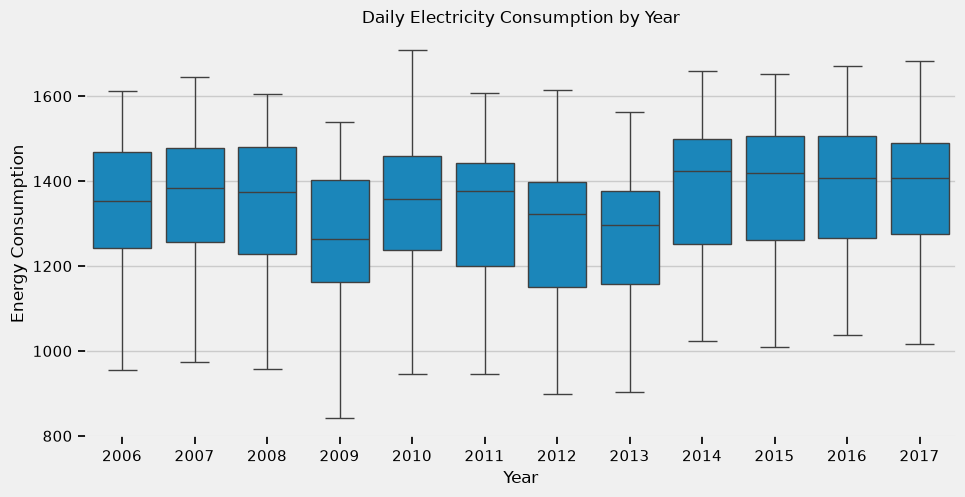

In [54]:
# Compare the distribution of daily electricity consumption across years.

plt.figure(figsize=(10, 5))

ax = sns.boxplot(
    x=opsd_daily['Year'],
    y=opsd_daily['Consumption']
)

ax.set_title('Daily Electricity Consumption by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Energy Consumption')

plt.show()

### 4.2 Aggregating Data by Year

To compare total energy consumption and production across years, we will aggregate the daily observations into yearly totals.

In [55]:
# Select the energy-related columns that we want to aggregate.

energy_columns = [
    'Consumption',
    'Wind',
    'Solar',
    'Wind+Solar'
]

# Aggregate the daily data by year.

opsd_annual = opsd_daily.groupby('Year')[energy_columns].sum()

# Display the yearly summary.

opsd_annual

,Consumption,Wind,Solar,Wind+Solar
Year,,,,
2006,489068.53600,0.000,0.000,0.000
2007,496631.84700,0.000,0.000,0.000
2008,495570.87600,0.000,0.000,0.000
2009,459737.42800,0.000,0.000,0.000
2010,488588.70000,35911.777,0.000,0.000
2011,484814.08600,44032.951,0.000,0.000
2012,469574.75400,45862.667,27887.332,73749.999
2013,463336.85300,47197.832,29559.780,76697.443
2014,504164.82100,51107.672,32498.307,83370.502


### 4.3 Showing Trends with Line Plots

A line plot is useful for showing how a numerical quantity changes over an ordered variable such as time.

We will first examine total electricity consumption for each year.

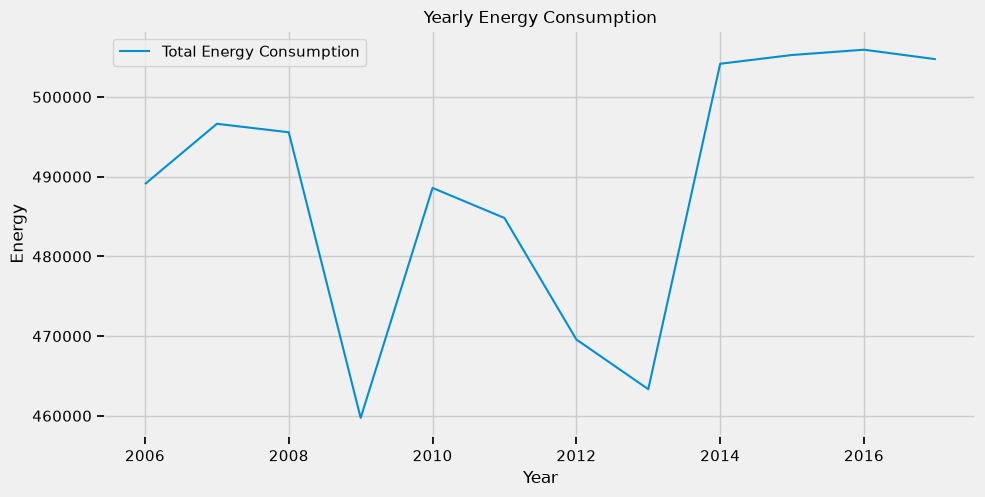

In [56]:
# Plot total yearly electricity consumption.

plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    x=opsd_annual.index,
    y=opsd_annual['Consumption'],
    label='Total Energy Consumption'
)

ax.set_title('Yearly Energy Consumption')
ax.set_xlabel('Year')
ax.set_ylabel('Energy')

plt.show()

### Comparing Renewable Energy Sources

We can use the same type of visualization to compare wind and solar production.

Using two lines allows us to examine how the two renewable sources changed over the same period.

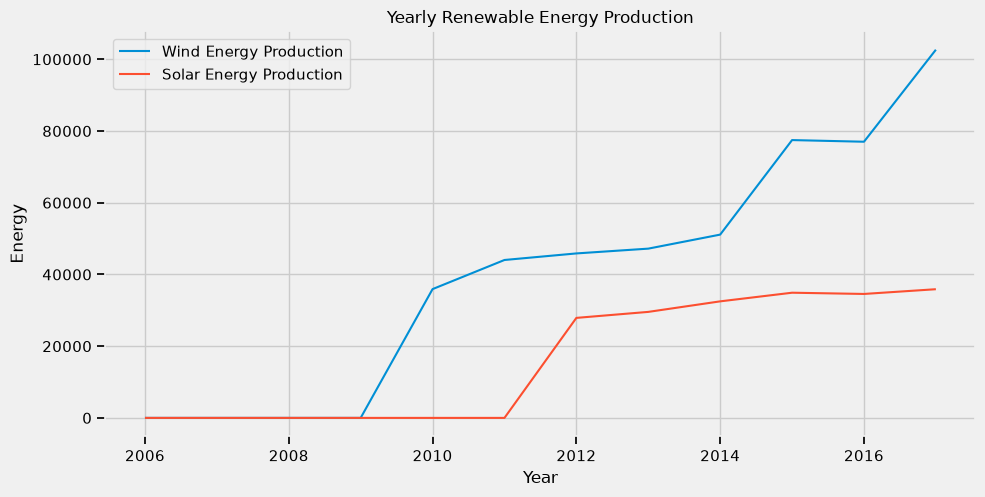

In [57]:
# Compare yearly wind and solar energy production.

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=opsd_annual.index,
    y=opsd_annual['Wind'],
    label='Wind Energy Production'
)

sns.lineplot(
    x=opsd_annual.index,
    y=opsd_annual['Solar'],
    label='Solar Energy Production'
)

plt.title('Yearly Renewable Energy Production')
plt.xlabel('Year')
plt.ylabel('Energy')

plt.show()

### 4.4 Calculating a Renewable Energy Proportion

Absolute energy production is useful, but it can also be useful to consider renewable production relative to total consumption.

We will calculate the percentage of yearly energy consumption represented by combined wind and solar production.

In [58]:
# Calculate the percentage of consumption represented by wind and solar.

opsd_annual['Wind+Solar/Consumption [%]'] = (
    opsd_annual['Wind+Solar']
    / opsd_annual['Consumption']
    * 100
)

# Display the calculated proportion.

opsd_annual

,Consumption,Wind,Solar,Wind+Solar,Wind+Solar/Consumption [%]
Year,,,,,
2006,489068.53600,0.000,0.000,0.000,0.000000
2007,496631.84700,0.000,0.000,0.000,0.000000
2008,495570.87600,0.000,0.000,0.000,0.000000
2009,459737.42800,0.000,0.000,0.000,0.000000
2010,488588.70000,35911.777,0.000,0.000,0.000000
2011,484814.08600,44032.951,0.000,0.000,0.000000
2012,469574.75400,45862.667,27887.332,73749.999,15.705699
2013,463336.85300,47197.832,29559.780,76697.443,16.553279
2014,504164.82100,51107.672,32498.307,83370.502,16.536358


### 4.5 Comparing Proportions with a Bar Plot

A bar plot is useful for comparing values across discrete categories.

Here, each bar represents the proportion of yearly energy consumption accounted for by wind and solar production.

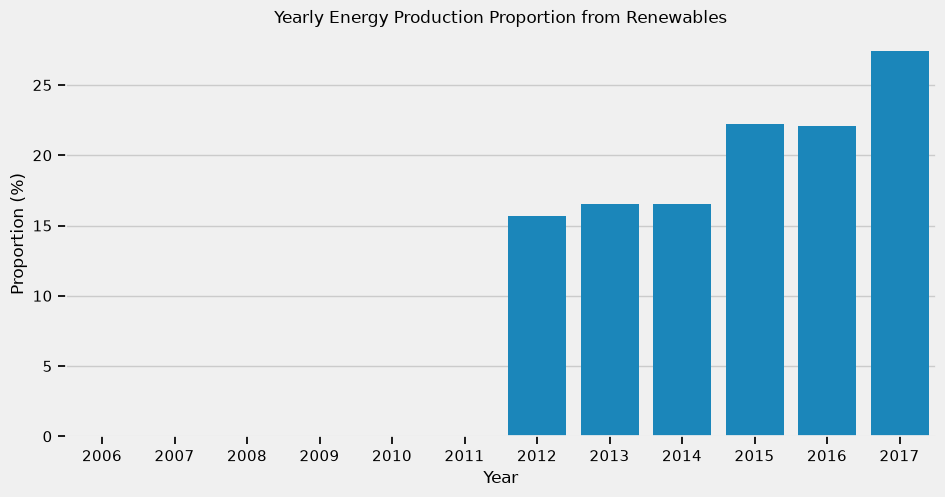

In [59]:
# Plot the yearly renewable-energy proportion.

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=opsd_annual.index,
    y=opsd_annual['Wind+Solar/Consumption [%]']
)

ax.set_title('Yearly Energy Production Proportion from Renewables')
ax.set_xlabel('Year')
ax.set_ylabel('Proportion (%)')

plt.show()

### Visualization Takeaways

In this section, we used several visualization types for different purposes:

| Visualization | What it helps us see |
|---|---|
| Boxplot | Distribution and variation across groups |
| Line plot | Trends over an ordered variable |
| Bar plot | Comparison between discrete categories |

The important principle is:

> **Choose the visualization based on the question you want to answer.**

We also saw how JSON data can move through a typical data-science workflow:

**JSON → DataFrame → Data preparation → Aggregation → Visualization**